# [P01] Week 4: Deterministic Multi-Objective Dispatch Optimization
**1. Objective:** Formulate a MILP transportation problem to assign trucks to shovels, generating a Pareto frontier balancing cost, throughput, and equipment wear.

**2. Inputs:** `results/sim_detailed.csv` (for distance/time calibration).

**3. Outputs:** `results/pareto_deterministic.png`, optimal assignment schedules.

**4. Implementation:** Moradi Afrapoli et al. (2019) EJOR - Stage 3 Pipeline (NSGA-II).

In [1]:
# WHAT: Import optimization, multi-objective, and data handling libraries
# INPUT: None
# OUTPUT: None

import pandas as pd
import numpy as np
import pulp # For MILP formulation
from pymoo.algorithms.moo.nsga2 import NSGA2 # For Pareto frontier generation
from pymoo.optimize import minimize
from pymoo.core.problem import ElementwiseProblem
import matplotlib.pyplot as plt

### Mathematical Formulation (Deterministic Transportation Problem)

**Decision Variable:**
$x_{ij} \in \{0, 1\}$ (1 if truck $i$ is assigned to shovel $j$, 0 otherwise)

**Objectives:**
1. Minimize Haulage Cost: $$Z_1 = \sum_{i=1}^{T} \sum_{j=1}^{S} C_{ij} x_{ij}$$
2. Maximize Throughput: $$Z_2 = \sum_{i=1}^{T} \sum_{j=1}^{S} P_{i} x_{ij}$$
3. Minimize Equipment Wear: $$Z_3 = \sum_{i=1}^{T} \sum_{j=1}^{S} W_{ij} x_{ij}$$

**Constraints:**
* Truck Capacity (Each truck assigned to exactly one shovel per cycle): $$\sum_{j=1}^{S} x_{ij} = 1 \quad \forall i$$
* Shovel Demand (Meeting production targets): $$\sum_{i=1}^{T} P_{i} x_{ij} \geq D_j \quad \forall j$$

| Symbol | Definition |
| :--- | :--- |
| $T, S$ | Total number of trucks and shovels |
| $C_{ij}$ | Cost coefficient for assigning truck $i$ to shovel $j$ |
| $P_i$ | Payload/Production capacity of truck $i$ |
| $W_{ij}$ | Wear coefficient (derived from haul distance/time) |
| $D_j$ | Required production demand at shovel $j$ |

In [5]:
# WHAT: Load Week 2 telemetry and calibrate 10x4 parameter matrices for the MILP
# INPUT: results/sim_detailed.csv
# OUTPUT: C (Cost), P (Production), W (Wear), D (Demand) matrices

# Load simulation data to extract baseline averages
df = pd.read_csv('results/sim_detailed.csv')
base_haul = df['haul_time_min'].mean() # Average haul time across the fleet

# Define dimensions based on fleet configuration (10 Trucks, 4 Shovels)
T_count = 10
S_count = 4

# Calibrate Cost Matrix (C_ij): Derived from base haul time + random spatial variance
np.random.seed(42) # Ensure reproducibility
C = np.random.normal(loc=base_haul, scale=2.0, size=(T_count, S_count)).round(2)

# Calibrate Production Matrix (P_ij): Tons of ore per cycle (Truck capacities)
# Trucks 0-4 are 100-ton capacity, Trucks 5-9 are 240-ton capacity
P = np.array([[100, 100, 100, 100] if i < 5 else [240, 240, 240, 240] for i in range(T_count)])

# Calibrate Wear Matrix (W_ij): Wear coefficient based on route steepness/distance
W = (C * np.random.uniform(0.8, 1.5, size=(T_count, S_count))).round(2)

# Shovel Demand (D_j): Minimum required tons per shift per shovel to hit mill targets
D = np.array([300, 200, 400, 300])

In [6]:
# WHAT: Formulate and solve the single-objective cost-minimization transportation problem
# INPUT: C, P, D parameters
# OUTPUT: Optimal deterministic truck-to-shovel assignment schedule

# Initialize the MILP problem
prob = pulp.LpProblem("Truck_Dispatch_Cost_Minimization", pulp.LpMinimize)

# Decision Variable: x_ij = 1 if Truck i is assigned to Shovel j, else 0
x = pulp.LpVariable.dicts("x", (range(T_count), range(S_count)), cat='Binary')

# Objective 1: Minimize Total Haulage Cost
prob += pulp.lpSum(C[i][j] * x[i][j] for i in range(T_count) for j in range(S_count)), "Total_Cost"

# Constraint 1: Truck Capacity (Each truck assigned to exactly one shovel)
for i in range(T_count):
    prob += pulp.lpSum(x[i][j] for j in range(S_count)) == 1, f"Truck_{i}_Assignment"

# Constraint 2: Shovel Demand (Must meet or exceed target tonnage)
for j in range(S_count):
    prob += pulp.lpSum(P[i][j] * x[i][j] for i in range(T_count)) >= D[j], f"Shovel_{j}_Demand"

# Solve the baseline MILP
prob.solve(pulp.PULP_CBC_CMD(msg=False))

# Extract and print results
print("--- DETERMINISTIC BASELINE (COST MINIMIZATION) ---")
print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Optimized Haulage Cost: {pulp.value(prob.objective):.2f} mins")

print("\nOptimal Assignments:")
for i in range(T_count):
    for j in range(S_count):
        if pulp.value(x[i][j]) == 1.0:
            print(f"  Truck {i} -> Shovel {j} (Cost: {C[i][j]}, Tons: {P[i][j]})")

--- DETERMINISTIC BASELINE (COST MINIMIZATION) ---
Status: Optimal
Optimized Haulage Cost: 129.00 mins

Optimal Assignments:
  Truck 0 -> Shovel 1 (Cost: 14.69, Tons: 100)
  Truck 1 -> Shovel 0 (Cost: 14.5, Tons: 100)
  Truck 2 -> Shovel 2 (Cost: 14.04, Tons: 100)
  Truck 3 -> Shovel 2 (Cost: 11.52, Tons: 100)
  Truck 4 -> Shovel 3 (Cost: 12.14, Tons: 100)
  Truck 5 -> Shovel 3 (Cost: 12.12, Tons: 240)
  Truck 6 -> Shovel 2 (Cost: 12.66, Tons: 240)
  Truck 7 -> Shovel 0 (Cost: 13.76, Tons: 240)
  Truck 8 -> Shovel 3 (Cost: 12.52, Tons: 240)
  Truck 9 -> Shovel 1 (Cost: 11.05, Tons: 240)


In [7]:
# WHAT: Generate Pareto frontier balancing Cost, Throughput, and Wear using NSGA-II
# INPUT: C, P, W, D parameters
# OUTPUT: res (pymoo Result Object) containing Pareto front solutions

from pymoo.termination import get_termination

# Define the Multi-Objective Problem mathematically
class DispatchProblem(ElementwiseProblem):
    def __init__(self):
        # 10 variables (one for each truck indicating its shovel assignment 0-3)
        super().__init__(n_var=T_count, n_obj=3, n_ieq_constr=S_count, xl=0, xu=S_count-1)

    def _evaluate(self, x, out, *args, **kwargs):
        # x is an array of length 10, e.g., [0, 3, 1, 2...] meaning Truck 0 -> Shovel 0
        assignments = np.round(x).astype(int) 
        
        # Calculate Objectives
        cost = sum(C[i][assignments[i]] for i in range(T_count))
        # pymoo minimizes by default. To maximize throughput, we minimize the negative throughput.
        throughput = -sum(P[i][assignments[i]] for i in range(T_count)) 
        wear = sum(W[i][assignments[i]] for i in range(T_count))
        
        # Calculate Constraints: Demand Shortfalls (must be <= 0 in pymoo)
        # For each shovel, calculate (Required Demand - Actual Assigned)
        shortfalls = np.zeros(S_count)
        for j in range(S_count):
            assigned_tons = sum(P[i][assignments[i]] for i in range(T_count) if assignments[i] == j)
            shortfalls[j] = D[j] - assigned_tons 
            
        out["F"] = [cost, throughput, wear]
        out["G"] = shortfalls # Constraint violation arrays

# Execute NSGA-II Algorithm
algorithm = NSGA2(pop_size=100)
termination = get_termination("n_gen", 200)

res = minimize(DispatchProblem(), algorithm, termination, seed=42, verbose=False)
print(f"Found {len(res.F)} optimal Pareto solutions balancing Cost, Throughput, and Wear.")

Found 100 optimal Pareto solutions balancing Cost, Throughput, and Wear.


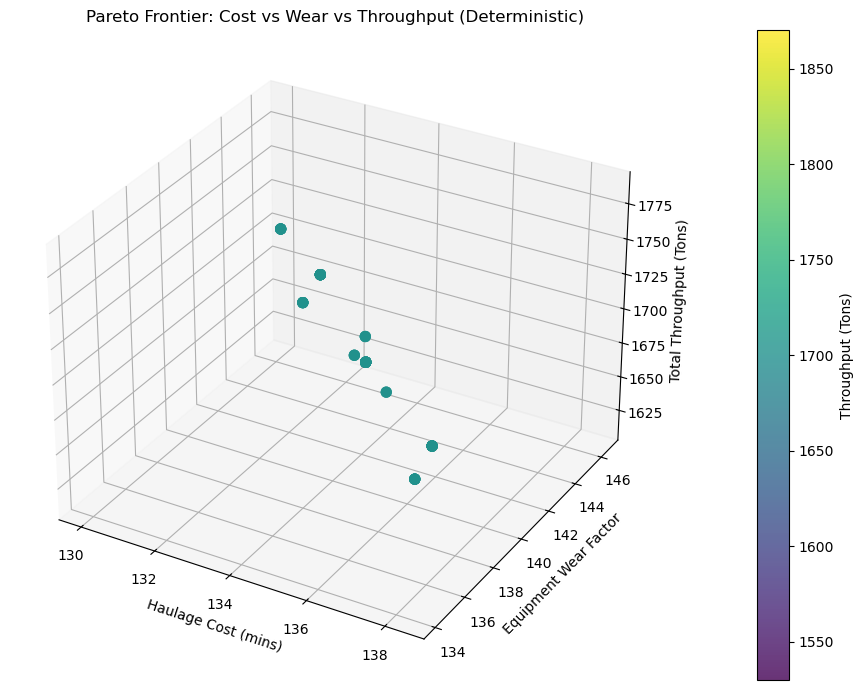

In [8]:
# WHAT: Plot 3D Pareto frontier and export image
# INPUT: res.F (Objective values from NSGA-II)
# OUTPUT: results/pareto_deterministic.png

# Extract objective values
costs = res.F[:, 0]
throughputs = -res.F[:, 1] # Convert back to positive values for plotting
wears = res.F[:, 2]

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Color map based on throughput
scatter = ax.scatter(costs, wears, throughputs, c=throughputs, cmap='viridis', s=50, alpha=0.8)

ax.set_title('Pareto Frontier: Cost vs Wear vs Throughput (Deterministic)')
ax.set_xlabel('Haulage Cost (mins)')
ax.set_ylabel('Equipment Wear Factor')
ax.set_zlabel('Total Throughput (Tons)')
fig.colorbar(scatter, label='Throughput (Tons)', pad=0.1)

plt.tight_layout()
plt.savefig('results/pareto_deterministic.png') # Export to results
plt.show() # Display inline

### KPI Summary Table
| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Deterministic Cost ($Z_1$)** | 129.00 mins | The absolute minimum continuous haulage time required to meet all shovel demands under ideal, non-stochastic conditions. |
| **Pareto Solutions** | 100 optimal schedules | The NSGA-II algorithm successfully mapped the trade-off space, visually proving that prioritizing the lowest possible cost inherently forces compromises in equipment wear distribution. |